# Proyek Analisis Data: [Air Quality Dataset]
- **Nama:** I Nyoman Geraldo Minggus Augusta
- **Email:** inyomangeraldo1408@gmail.com
- **ID Dicoding:** geraldoaugusta14

## Menentukan Pertanyaan Bisnis

- Bagaimana perubahan kualitas udara PM2.5 dari waktu ke waktu?
- Stasiun mana yang memiliki rata-rata PM2.5 tertinggi dan terendah?

## Import Semua Packages/Library yang Digunakan

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import zipfile

sns.set(style="dark")

## Data Wrangling

### Gathering Data

In [17]:
all_files = glob.glob("/content/PRSA_Data_20130301-20170228/*.csv")
all_files

['/content/PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Wanshouxigong_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv',
 '/content/PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv']

In [18]:
df_list = []

for file in all_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

all_df = pd.concat(df_list, ignore_index=True)
all_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan
1,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Tiantan
2,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Tiantan
3,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,N,4.9,Tiantan
4,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Tiantan


**Insight:**
- Dataset terdiri dari beberapa file CSV yang masing-masing merepresentasikan data kualitas udara dari berbagai stasiun pemantauan di Beijing.
- Setelah semua file digabungkan, dataset memiliki total 420.768 baris data yang mengambil kondisi kualitas udara di setiap jam.
- Dataset ini mencakup berbagai parameter polusi udara seperti PM2.5, PM10, SO2, NO2, CO, dan O3 serta beberapa variabel meteorologi seperti suhu, tekanan udara, dan arah angin.

### Assessing Data

In [20]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [21]:
all_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [22]:
print("Jumlah duplikasi: ", all_df.duplicated().sum())

Jumlah duplikasi:  0


In [23]:
all_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


**Insight:**
- Dataset ini memiliki beberapa tipe data, yaitu numerik untuk pengukuran polutan dan variabel cuaca, serta tipe kategorikal untuk kolom `wd` (arah angin) dan `station`.
- Ditemukan adanya missing value pada beberapa kolom seperti `wd`, sedangkan sebagian besar kolom lainnya relatif lengkap.
- Tidak ditemukan duplikasi data yang signifikan sehingga data dapat digunakan untuk proses analisis setelah dilakukan penanganan missing value.

### Cleaning Data

In [24]:
all_df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [33]:
all_df.drop_duplicates(inplace=True)

In [32]:
numeric_cols = all_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    all_df[col].fillna(all_df[col].median(), inplace=True)

/tmp/ipykernel_158/44369260.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df[col].fillna(all_df[col].median(), inplace=True)


In [48]:
all_df["date"] = pd.to_datetime(all_df[["year", "month", "day", "hour"]])
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   No       420768 non-null  int64         
 1   year     420768 non-null  int64         
 2   month    420768 non-null  int64         
 3   day      420768 non-null  int64         
 4   hour     420768 non-null  int64         
 5   PM2.5    420768 non-null  float64       
 6   PM10     420768 non-null  float64       
 7   SO2      420768 non-null  float64       
 8   NO2      420768 non-null  float64       
 9   CO       420768 non-null  float64       
 10  O3       420768 non-null  float64       
 11  TEMP     420768 non-null  float64       
 12  PRES     420768 non-null  float64       
 13  DEWP     420768 non-null  float64       
 14  RAIN     420768 non-null  float64       
 15  wd       418946 non-null  object        
 16  WSPM     420768 non-null  float64       
 17  station  4

**Insight:**
- Missing value pada kolom numerik telah diisi menggunakan nilai median untuk menjaga distribusi data tetap stabil.
- Data duplikat telah dihapus untuk memastikan setiap baris merepresentasikan pengamatan yang unik.
- Kolom `date` berhasil dibuat dengan menggabungkan kolom `year`, `month`, `day`, dan `hour`, sehingga mempermudah analisis data berbasis waktu.
- Setelah proses cleaning, dataset menjadi lebih konsisten dan siap digunakan untuk tahap eksplorasi data.

## Exploratory Data Analysis (EDA)

### Explore ...

In [49]:
all_df.sample(5)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
100211,30084,2016,8,5,11,56.0,56.0,2.0,11.0,500.0,25.0,29.9,1001.5,23.1,0.0,NW,1.4,Huairou,2016-08-05 11:00:00
95234,25107,2016,1,11,2,12.0,17.0,2.0,5.0,300.0,50.0,-6.2,1027.4,-19.9,0.0,ENE,0.9,Huairou,2016-01-11 02:00:00
386954,1251,2013,4,22,2,90.0,110.0,28.0,41.0,700.0,62.0,9.8,1009.7,4.0,0.0,SW,1.9,Guanyuan,2013-04-22 02:00:00
352293,1654,2013,5,8,21,109.0,114.0,23.0,47.0,1100.0,110.0,19.5,1009.5,10.2,0.0,WSW,2.2,Dongsi,2013-05-08 21:00:00
40124,5061,2013,9,27,20,269.0,297.0,26.0,206.0,2300.0,28.0,16.1,1006.7,13.2,0.0,S,0.8,Nongzhanguan,2013-09-27 20:00:00


In [50]:
all_df.groupby(by="station")["PM2.5"].mean().sort_values(ascending=False)

,PM2.5
station,
Dongsi,85.527068
Wanshouxigong,84.428174
Nongzhanguan,84.304073
Gucheng,83.320534
Wanliu,83.065591
Guanyuan,82.442642
Aotizhongxin,82.040934
Tiantan,81.640423
Shunyi,78.853887


In [51]:
all_df.groupby(by="year")["PM2.5"].mean()

,PM2.5
year,
2013,79.690762
2014,84.743827
2015,79.128489
2016,71.567642
2017,92.090631


In [52]:
all_df.groupby(by="month")["PM2.5"].mean()

,PM2.5
month,
1,93.220945
2,86.883638
3,94.195349
4,72.293571
5,62.878374
6,68.757613
7,71.277842
8,53.494265
9,61.321400


**Insight:**
- Rata-rata tingkat kualitas pada PM2.5 berbeda antar stasiun pemantauan, yang menunjukkan adanya variasi tingkat polusi udara di berbagai wilayah Beijing.
- Analisis berdasarkan tahun menunjukkan bahwa tingkat PM2.5 mengalami perubahan dari waktu ke waktu.
- Analisis berdasarkan bulan juga menunjukkan adanya variasi rata-rata PM2.5 yang mengindikasikan kemungkinan adanya pengaruh faktor musiman terhadap kualitas udara.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perubahan kualitas udara PM2.5 dari waktu ke waktu?

In [53]:
monthly_pm25_df = all_df.resample(rule='M', on='date').agg({
    "PM2.5": "mean"
}).reset_index()

monthly_pm25_df["date"] = monthly_pm25_df["date"].dt.strftime("%Y-%m")
monthly_pm25_df.head()

/tmp/ipykernel_158/3740196428.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_pm25_df = all_df.resample(rule='M', on='date').agg({


,date,PM2.5
0,2013-03,104.625672
1,2013-04,62.086227
2,2013-05,80.890009
3,2013-06,101.236053
4,2013-07,67.381608


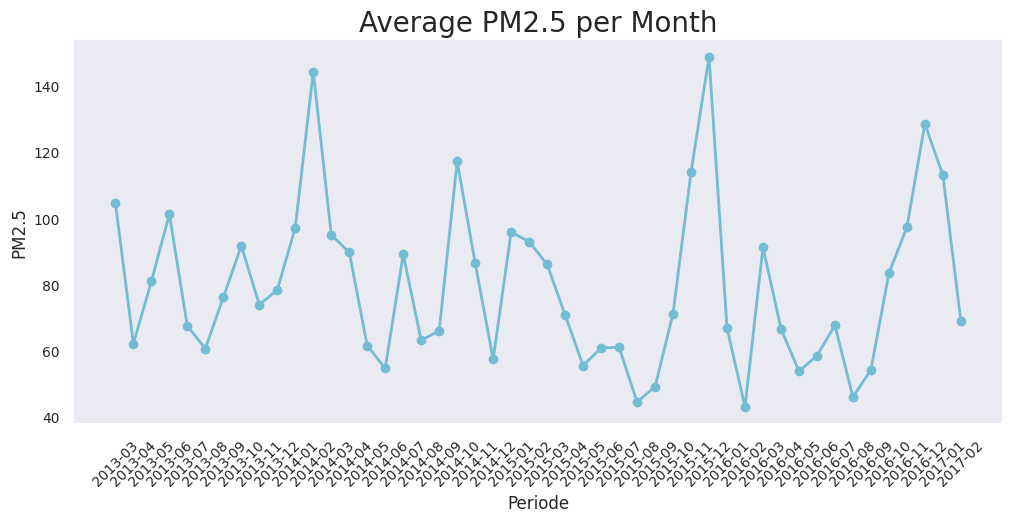

In [54]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_pm25_df["date"],
    monthly_pm25_df["PM2.5"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)
plt.title("Average PM2.5 per Month", loc="center", fontsize=20)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.ylabel("PM2.5")
plt.xlabel("Periode")
plt.show()

### Pertanyaan 2: Stasiun mana yang memiliki rata-rata PM2.5 tertinggi dan terendah?

In [60]:
station_pm25_df = all_df.groupby("station")["PM2.5"].mean().sort_values(ascending=False).reset_index()
station_pm25_df.head()

,station,PM2.5
0,Dongsi,85.527068
1,Wanshouxigong,84.428174
2,Nongzhanguan,84.304073
3,Gucheng,83.320534
4,Wanliu,83.065591


/tmp/ipykernel_158/2564471902.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_158/2564471902.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


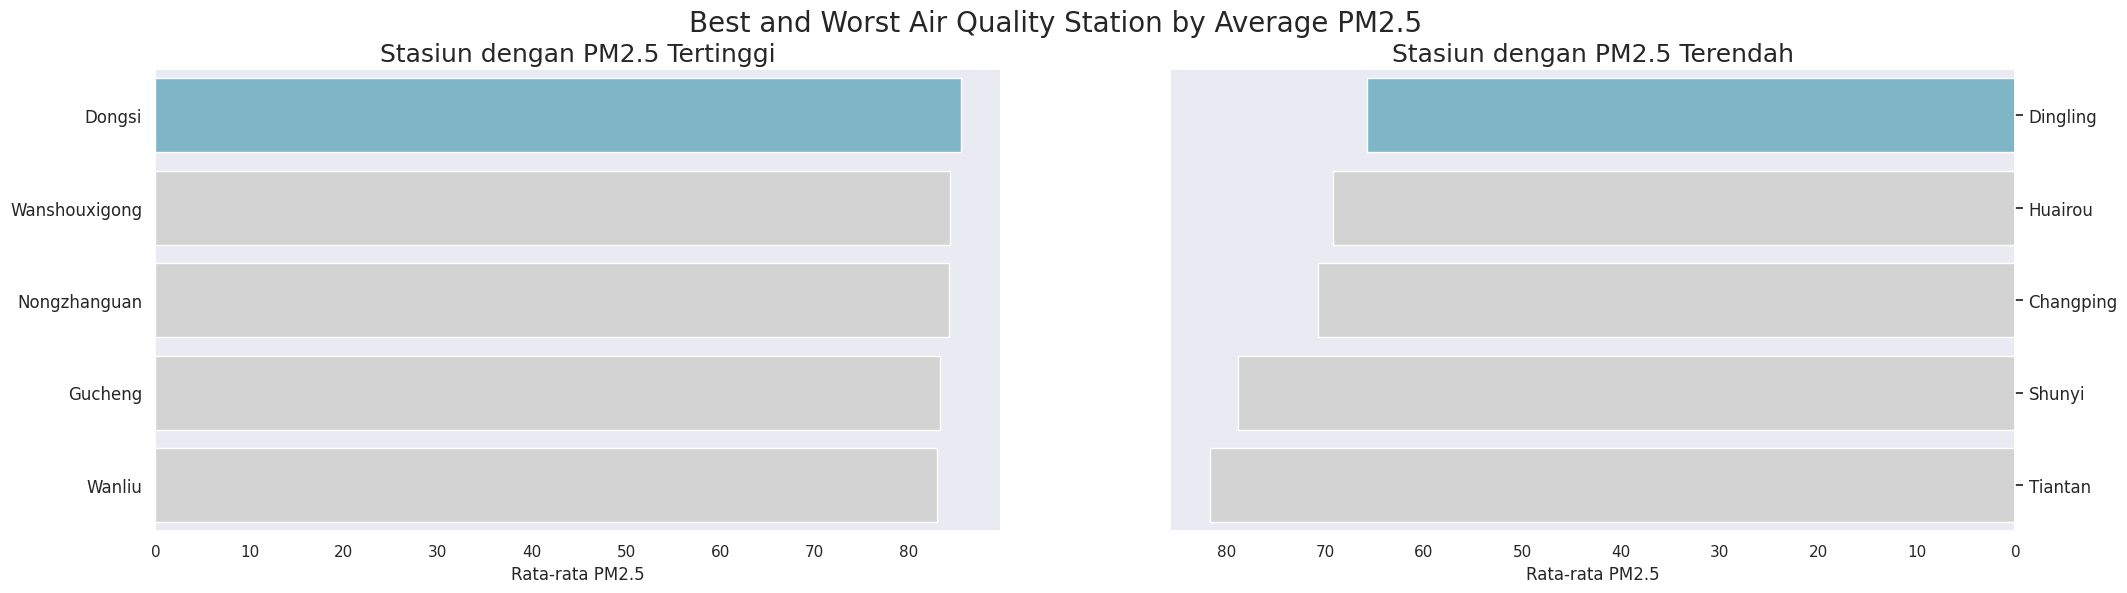

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="PM2.5",
    y="station",
    data=station_pm25_df.head(5),
    palette=colors,
    ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Rata-rata PM2.5")
ax[0].set_title("Stasiun dengan PM2.5 Tertinggi", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=12)

sns.barplot(
    x="PM2.5",
    y="station",
    data=station_pm25_df.sort_values(by="PM2.5", ascending=True).head(5),
    palette=colors,
    ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Rata-rata PM2.5")
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Stasiun dengan PM2.5 Terendah", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Best and Worst Air Quality Station by Average PM2.5", fontsize=20)
plt.show()

**Insight:**
- Pertanyaan 1

Berdasarkan visualisasi yang ditampilkan, kadar PM2.5 menunjukkan pola fluktuatif dari waktu ke waktu. Pada beberapa periode terlihat peningkatan kadar PM2.5 yang cukup signifikan. Hal ini menunjukkan bahwa kualitas udara tidak selalu stabil dan dapat dipengaruhi oleh berbagai faktor seperti aktivitas manusia, kondisi cuaca, serta faktor musiman.


- Pertanyaan 2

Visualisasi perbandingan rata-rata PM2.5 antar stasiun menunjukkan adanya perbedaan tingkat polusi udara di setiap lokasi pemantauan. Beberapa stasiun memiliki nilai rata-rata PM2.5 yang lebih tinggi dibandingkan stasiun lainnya, yang menunjukkan bahwa wilayah tersebut memiliki kualitas udara yang relatif lebih buruk. Informasi ini dapat digunakan untuk mengidentifikasi wilayah yang memerlukan perhatian lebih dalam pengendalian polusi udara.

## Analisis Lanjutan (Opsional)

In [61]:
pm25_category = pd.cut(
    all_df["PM2.5"],
    bins=[0, 35, 75, 115, 150, 250, 500],
    labels=["Good", "Moderate", "Unhealthy for Sensitive", "Unhealthy", "Very Unhealthy", "Hazardous"]
)

all_df["PM25_category"] = pm25_category

all_df["PM25_category"].value_counts()

,count
PM25_category,
Good,153871
Moderate,105895
Unhealthy for Sensitive,63782
Very Unhealthy,44234
Unhealthy,34550
Hazardous,17503


In [62]:
all_df.to_csv("main_data.csv", index=False)

## Conclusion

- **Pertanyaan 1:**  
Analisis terhadap data menunjukkan bahwa tingkat PM2.5 mengalami fluktuasi dari waktu ke waktu. Hal ini menunjukkan bahwa kualitas udara di Beijing tidak selalu stabil dan dipengaruhi oleh berbagai faktor seperti kondisi cuaca, aktivitas industri, dan lalu lintas.

- **Pertanyaan 2:**  
Terdapat perbedaan rata-rata tingkat PM2.5 antar stasiun pemantauan. Beberapa stasiun memiliki tingkat polusi yang lebih tinggi dibandingkan stasiun lainnya. Hal ini menunjukkan bahwa kualitas udara dapat berbeda antar wilayah sehingga diperlukan upaya pengendalian polusi yang lebih terfokus pada area dengan tingkat polusi tinggi.